# Seasonal Agriculture Performance Analysis

### Major Project – Data Analytics

**Objective:**  
To analyze agricultural performance across different seasons and identify
meaningful patterns, trends, relationships, variations, and differences
in agricultural performance.

## 1. Introduction

Agricultural performance is influenced by several factors such as seasonal
conditions, rainfall, temperature, soil characteristics, farming practices,
resource usage, market prices, and production costs.

This project analyzes agricultural data collected across different seasons,
geographical areas, crops, environmental conditions, resource usage, and
economic indicators.

The analysis aims to identify seasonal patterns, compare agricultural
performance, investigate relationships between environmental and farming
conditions, and derive evidence-based insights for better seasonal
agricultural planning.

## 2. Problem Statement

Agricultural activities are influenced by seasonal variations in environmental
conditions, farming practices, resource availability, and market conditions.

Raw agricultural data does not clearly explain how agricultural performance
changes across seasons.

Therefore, this project analyzes the available agricultural dataset to
identify seasonal differences, trends, relationships, variations, and
unusual patterns in agricultural performance.

## 3. Objectives

The objectives of this project are:

1. Understand the agricultural dataset.
2. Clean and prepare the data for analysis.
3. Compare agricultural performance across seasons.
4. Identify important seasonal patterns and trends.
5. Analyze crop performance across different seasons.
6. Investigate relationships between environmental conditions and yield.
7. Examine resource usage across seasons.
8. Analyze economic performance including revenue, cost, and profit.
9. Identify unusual patterns and outliers.
10. Develop evidence-based recommendations.

In [3]:
# Import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import pearsonr

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [4]:
#Load the dataset

df = pd.read_csv("seasonal_agriculture_performance_dataset.csv")

df.head()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,7.14,32.8,75.8,61.3,91.0,Drip,242.7,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,5.20,32.0,82.1,35.4,121.8,Flood,271.4,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,5.82,8.1,118.5,51.5,117.9,Drip,162.6,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,5.98,23.7,138.6,55.6,115.5,Rainfed,182.2,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,6.90,29.3,124.1,69.0,121.4,Flood,244.9,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


In [5]:
#Check dataset size

df.shape

(4000, 28)

In [6]:
# Display all columns

df.columns

Index(['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Farm_Area_Hectares',
       'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct',
       'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha',
       'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Irrigation_Method',
       'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score',
       'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne',
       'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3',
       'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct'],
      dtype='str')

In [7]:
# Understand the data
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   str    
 1   State                          4000 non-null   str    
 2   District                       4000 non-null   str    
 3   Crop                           4000 non-null   str    
 4   Season                         4000 non-null   str    
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   float64
 13 

In [8]:
df.describe()

,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
count,4000.000000,3952.000000,4000.00000,4000.000000,4000.000000,4000.000000,3960.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,3968.000000,4000.000000,4000.000000,4.000000e+03,4.000000e+03,4.000000e+03,4000.000000,4000.000000,4000.000000
mean,7.888265,601.152657,26.81890,63.210500,7.323050,6.701010,26.508232,120.250825,57.781850,104.760050,186.036000,5.070935,0.826138,5.270595,43.246210,44714.166250,5.263036e+05,6.378600e+05,1.115565e+05,6045.570250,5.385214,46.365875
std,4.223764,288.925025,3.81818,11.960834,1.121186,0.641461,6.712484,31.216452,17.015074,27.742681,60.260583,1.978879,0.101747,13.361398,126.880521,30266.161922,2.944191e+05,6.369747e+05,5.450819e+05,5572.944306,8.838101,12.424417
min,0.500000,80.000000,16.20000,25.000000,3.500000,5.200000,8.000000,40.000000,15.000000,30.000000,40.000000,0.500000,0.650000,0.300000,0.150000,2594.000000,2.682600e+04,6.107000e+03,-1.019223e+06,128.000000,0.135000,5.000000
25%,4.260000,370.200000,23.90000,54.775000,6.600000,6.260000,21.700000,98.500000,46.200000,86.200000,143.975000,3.690000,0.740000,1.050000,5.020000,21429.250000,2.745775e+05,2.075172e+05,-1.487318e+05,2268.750000,1.661000,37.300000
50%,7.895000,582.000000,26.90000,63.000000,7.300000,6.690000,26.400000,120.100000,57.500000,105.100000,186.250000,5.120000,0.830000,1.740000,11.770000,25913.000000,5.190825e+05,4.568305e+05,3.673000e+03,4435.000000,2.937500,46.400000
75%,11.650000,834.950000,29.60000,71.900000,8.100000,7.140000,31.300000,141.225000,69.400000,123.600000,227.200000,6.400000,0.910000,2.840000,24.355000,68279.000000,7.619965e+05,8.368748e+05,2.161878e+05,7829.750000,5.150250,54.900000
max,15.000000,1395.200000,39.70000,95.000000,11.000000,8.400000,47.000000,220.000000,120.000000,200.000000,400.000000,12.080000,1.000000,101.440000,1424.400000,131240.000000,1.349990e+06,5.080900e+06,4.345421e+06,40902.000000,79.800000,88.900000


In [9]:
# Check missing values

df.isnull().sum()

Farm_ID                           0
State                             0
District                          0
Crop                              0
Season                            0
Farm_Area_Hectares                0
Rainfall_mm                      48
Avg_Temperature_C                 0
Humidity_pct                      0
Sunlight_Hours_Day                0
Soil_pH                           0
Soil_Moisture_pct                40
Nitrogen_kg_ha                    0
Phosphorus_kg_ha                  0
Potassium_kg_ha                   0
Irrigation_Method                 0
Fertilizer_kg_ha                  0
Pesticide_Litre_ha                0
Seed_Quality_Score                0
Yield_Tonnes_Ha                  32
Production_Tonnes                 0
Market_Price_INR_Tonne            0
Total_Cost_INR                    0
Revenue_INR                       0
Profit_INR                        0
Water_Used_m3                     0
Water_Efficiency_t_per_1000m3     0
Disease_Pest_Risk_pct       

In [10]:
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_percentage.sort_values(ascending=False)

Rainfall_mm                      1.2
Soil_Moisture_pct                1.0
Yield_Tonnes_Ha                  0.8
Farm_ID                          0.0
Crop                             0.0
District                         0.0
Farm_Area_Hectares               0.0
Season                           0.0
Avg_Temperature_C                0.0
Humidity_pct                     0.0
Sunlight_Hours_Day               0.0
State                            0.0
Soil_pH                          0.0
Nitrogen_kg_ha                   0.0
Potassium_kg_ha                  0.0
Phosphorus_kg_ha                 0.0
Irrigation_Method                0.0
Fertilizer_kg_ha                 0.0
Pesticide_Litre_ha               0.0
Seed_Quality_Score               0.0
Production_Tonnes                0.0
Market_Price_INR_Tonne           0.0
Total_Cost_INR                   0.0
Revenue_INR                      0.0
Profit_INR                       0.0
Water_Used_m3                    0.0
Water_Efficiency_t_per_1000m3    0.0
D

### Missing Value Analysis

The dataset was checked for missing values. Missing values were identified in
three columns: Rainfall_mm (1.2%), Soil_Moisture_pct (1.0%), and
Yield_Tonnes_Ha (0.8%). All other columns contained no missing values.

Since the percentage of missing values is relatively low, appropriate data
cleaning and imputation techniques will be applied before further analysis.

In [11]:
# Check duplicate records
df.duplicated().sum()

np.int64(0)

### Duplicate Analysis

The dataset was checked for duplicate records. No duplicate records were
identified.

In [12]:
# Check categorical variables

print("States:")
print(df["State"].unique())

print("\nCrops:")
print(df["Crop"].unique())

print("\nSeasons:")
print(df["Season"].unique())

print("\nIrrigation Methods:")
print(df["Irrigation_Method"].unique())

States:
<StringArray>
['Andhra Pradesh',    'Maharashtra',      'Telangana',      'Karnataka',
        'Gujarat',     'Tamil Nadu',         'Punjab', 'Madhya Pradesh']
Length: 8, dtype: str

Crops:
<StringArray>
[    'Wheat',     'Maize',    'Pulses',      'Rice',    'Cotton',    'Chilli',
 'Groundnut', 'Sugarcane']
Length: 8, dtype: str

Seasons:
<StringArray>
['Kharif', 'Rabi', 'Zaid']
Length: 3, dtype: str

Irrigation Methods:
<StringArray>
['Drip', 'Flood', 'Rainfed', 'Sprinkler']
Length: 4, dtype: str


In [13]:
# Data Cleaning
data = df.copy()

In [14]:
# Check duplicate rows:
data = data.drop_duplicates()

In [15]:
# Check missing values:
data.isnull().sum()

Farm_ID                           0
State                             0
District                          0
Crop                              0
Season                            0
Farm_Area_Hectares                0
Rainfall_mm                      48
Avg_Temperature_C                 0
Humidity_pct                      0
Sunlight_Hours_Day                0
Soil_pH                           0
Soil_Moisture_pct                40
Nitrogen_kg_ha                    0
Phosphorus_kg_ha                  0
Potassium_kg_ha                   0
Irrigation_Method                 0
Fertilizer_kg_ha                  0
Pesticide_Litre_ha                0
Seed_Quality_Score                0
Yield_Tonnes_Ha                  32
Production_Tonnes                 0
Market_Price_INR_Tonne            0
Total_Cost_INR                    0
Revenue_INR                       0
Profit_INR                        0
Water_Used_m3                     0
Water_Efficiency_t_per_1000m3     0
Disease_Pest_Risk_pct       

In [16]:
# Standardize text columns:

text_columns = ["State", "District", "Crop", "Season", "Irrigation_Method"]

for col in text_columns:
    data[col] = data[col].astype(str).str.strip()

In [17]:
# to verify:

data.info()

<class 'pandas.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   str    
 1   State                          4000 non-null   str    
 2   District                       4000 non-null   str    
 3   Crop                           4000 non-null   str    
 4   Season                         4000 non-null   str    
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   float64
 13 

In [18]:
# Check impossible values
numeric_columns = data.select_dtypes(include=np.number).columns

negative_values = {}

for col in numeric_columns:
    count = (data[col] < 0).sum()
    if count > 0:
        negative_values[col] = count

negative_values

{'Profit_INR': np.int64(1966)}

In [19]:
# Basic descriptive analysis
data.describe().T

,count,mean,std,min,25%,50%,75%,max
Farm_Area_Hectares,4000.0,7.888265,4.223764,0.500,4.260,7.8950,11.65000,15.00
Rainfall_mm,3952.0,601.152657,288.925025,80.000,370.200,582.0000,834.95000,1395.20
Avg_Temperature_C,4000.0,26.818900,3.818180,16.200,23.900,26.9000,29.60000,39.70
Humidity_pct,4000.0,63.210500,11.960834,25.000,54.775,63.0000,71.90000,95.00
Sunlight_Hours_Day,4000.0,7.323050,1.121186,3.500,6.600,7.3000,8.10000,11.00
Soil_pH,4000.0,6.701010,0.641461,5.200,6.260,6.6900,7.14000,8.40
Soil_Moisture_pct,3960.0,26.508232,6.712484,8.000,21.700,26.4000,31.30000,47.00
Nitrogen_kg_ha,4000.0,120.250825,31.216452,40.000,98.500,120.1000,141.22500,220.00
Phosphorus_kg_ha,4000.0,57.781850,17.015074,15.000,46.200,57.5000,69.40000,120.00
Potassium_kg_ha,4000.0,104.760050,27.742681,30.000,86.200,105.1000,123.60000,200.00


In [20]:
# We can also calculate:
data[[
    "Yield_Tonnes_Ha",
    "Production_Tonnes",
    "Revenue_INR",
    "Profit_INR",
    "Water_Used_m3"
]].mean()

Yield_Tonnes_Ha           5.270595
Production_Tonnes        43.246210
Revenue_INR          637860.048000
Profit_INR           111556.465000
Water_Used_m3          6045.570250
dtype: float64

In [21]:
# Number of farms by season
season_counts = data["Season"].value_counts()
season_counts

Season
Kharif    1779
Rabi      1627
Zaid       594
Name: count, dtype: int64

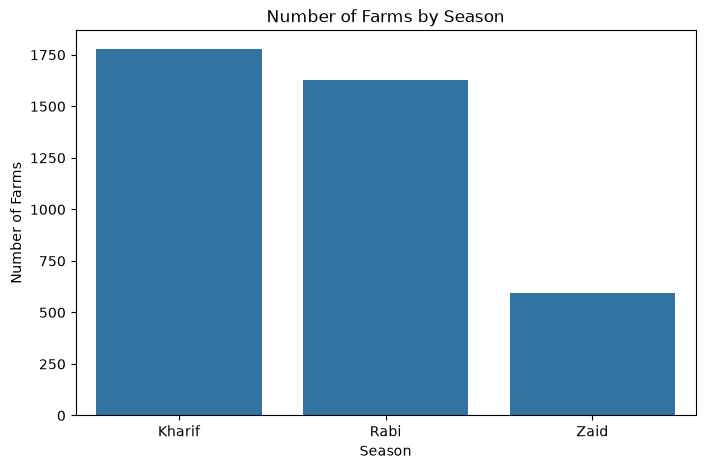

In [22]:
# Visualization:

plt.figure(figsize=(8,5))
sns.countplot(data=data, x="Season")
plt.title("Number of Farms by Season")
plt.xlabel("Season")
plt.ylabel("Number of Farms")
plt.show()

In [23]:
# Main analysis: Season performance
season_performance = data.groupby("Season").agg({
    "Yield_Tonnes_Ha": "mean",
    "Production_Tonnes": "mean",
    "Revenue_INR": "mean",
    "Profit_INR": "mean",
    "Water_Used_m3": "mean",
    "Water_Efficiency_t_per_1000m3": "mean",
    "Disease_Pest_Risk_pct": "mean"
}).round(2)

season_performance

,Yield_Tonnes_Ha,Production_Tonnes,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
Season,,,,,,,
Kharif,5.64,46.31,710719.06,178914.65,6102.20,5.89,54.47
Rabi,5.08,41.49,601526.05,87689.47,5846.99,5.19,40.48
Zaid,4.67,38.89,519171.90,-24804.82,6419.89,4.41,38.22


In [24]:
# Average yield by season
season_yield = (
    data.groupby("Season")["Yield_Tonnes_Ha"]
    .mean()
    .sort_values(ascending=False)
)
season_yield

Season
Kharif    5.643973
Rabi      5.080498
Zaid      4.665942
Name: Yield_Tonnes_Ha, dtype: float64

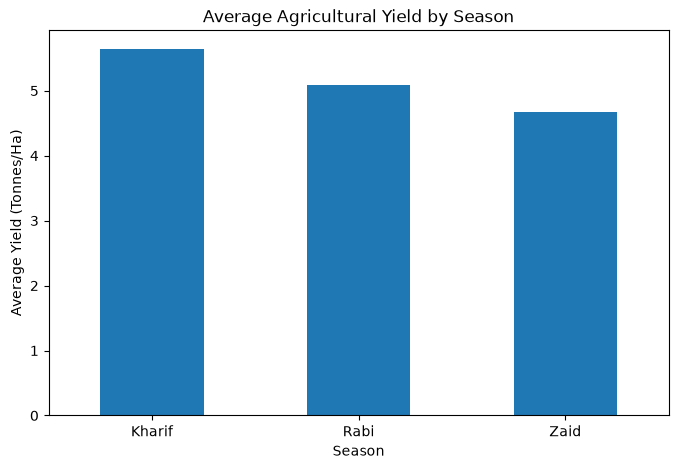

In [25]:
# Plot:

plt.figure(figsize=(8,5))
season_yield.plot(kind="bar")
plt.title("Average Agricultural Yield by Season")
plt.xlabel("Season")
plt.ylabel("Average Yield (Tonnes/Ha)")
plt.xticks(rotation=0)
plt.show()

In [26]:
# Profit by season
season_profit = (
    data.groupby("Season")["Profit_INR"]
    .mean()
    .sort_values(ascending=False)
)
season_profit

Season
Kharif    178914.647555
Rabi       87689.470191
Zaid      -24804.824916
Name: Profit_INR, dtype: float64

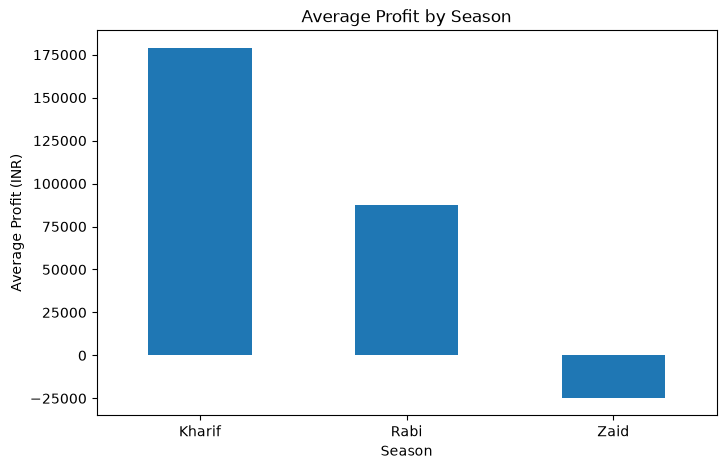

In [27]:
# Plot:

plt.figure(figsize=(8,5))
season_profit.plot(kind="bar")
plt.title("Average Profit by Season")
plt.xlabel("Season")
plt.ylabel("Average Profit (INR)")
plt.xticks(rotation=0)
plt.show()

In [28]:
# Water efficiency by season
water_efficiency = (
    data.groupby("Season")["Water_Efficiency_t_per_1000m3"]
    .mean()
    .sort_values(ascending=False)
)
water_efficiency

Season
Kharif    5.891834
Rabi      5.186122
Zaid      4.413239
Name: Water_Efficiency_t_per_1000m3, dtype: float64

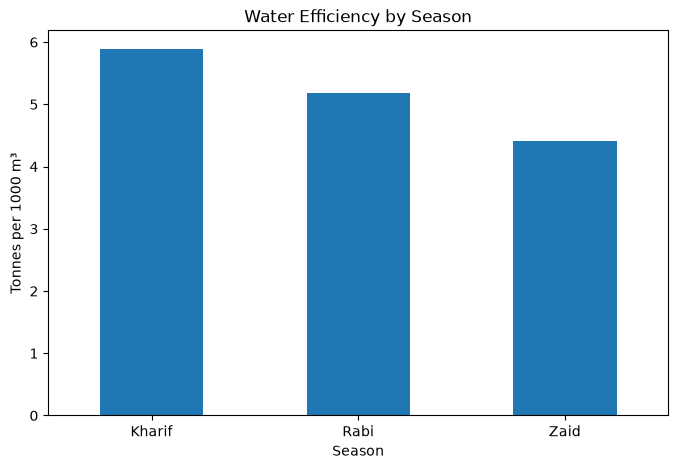

In [29]:
# Plot:

plt.figure(figsize=(8,5))
water_efficiency.plot(kind="bar")
plt.title("Water Efficiency by Season")
plt.xlabel("Season")
plt.ylabel("Tonnes per 1000 m³")
plt.xticks(rotation=0)
plt.show()

In [30]:
# Crop analysis
# Find the crops:

data["Crop"].value_counts()

Crop
Rice         690
Wheat        614
Maize        551
Cotton       508
Pulses       496
Groundnut    424
Chilli       412
Sugarcane    305
Name: count, dtype: int64

In [31]:
# Calculate average yield:

crop_yield = (
    data.groupby("Crop")["Yield_Tonnes_Ha"]
    .mean()
    .sort_values(ascending=False)
)
crop_yield

Crop
Sugarcane    46.938746
Maize         2.717130
Rice          2.439413
Wheat         2.109216
Chilli        1.540344
Groundnut     1.317924
Cotton        1.225734
Pulses        0.918198
Name: Yield_Tonnes_Ha, dtype: float64

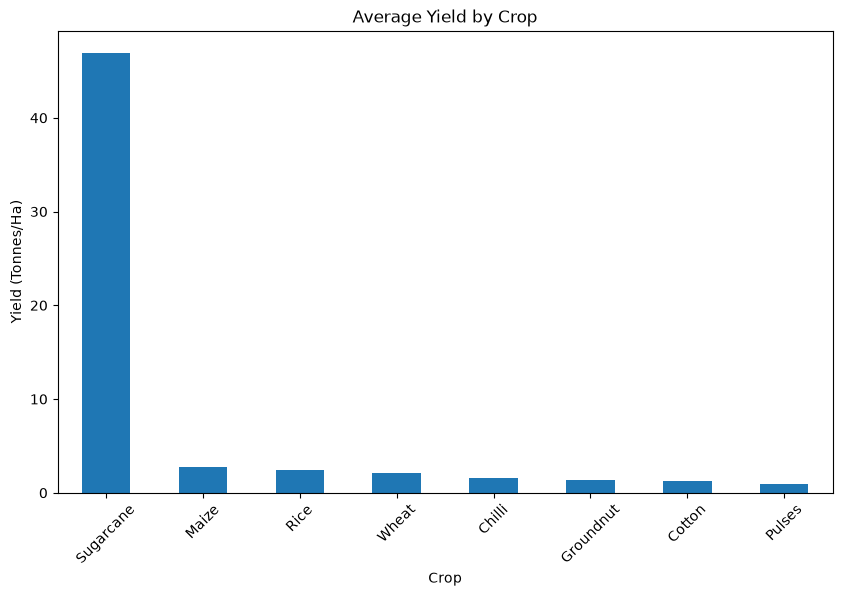

In [32]:
# Plot:

plt.figure(figsize=(10,6))
crop_yield.plot(kind="bar")
plt.title("Average Yield by Crop")
plt.xlabel("Crop")
plt.ylabel("Yield (Tonnes/Ha)")
plt.xticks(rotation=45)
plt.show()

In [33]:
# Crop × Season analysis
crop_season_yield = pd.pivot_table(
    data,
    values="Yield_Tonnes_Ha",
    index="Crop",
    columns="Season",
    aggfunc="mean"
)
crop_season_yield.round(2)

Season,Kharif,Rabi,Zaid
Crop,,,
Chilli,1.73,1.46,1.18
Cotton,1.37,1.19,0.95
Groundnut,1.48,1.22,1.04
Maize,2.97,2.61,2.30
Pulses,1.04,0.87,0.65
Rice,2.71,2.33,1.90
Sugarcane,53.46,43.94,38.42
Wheat,2.26,2.06,1.75


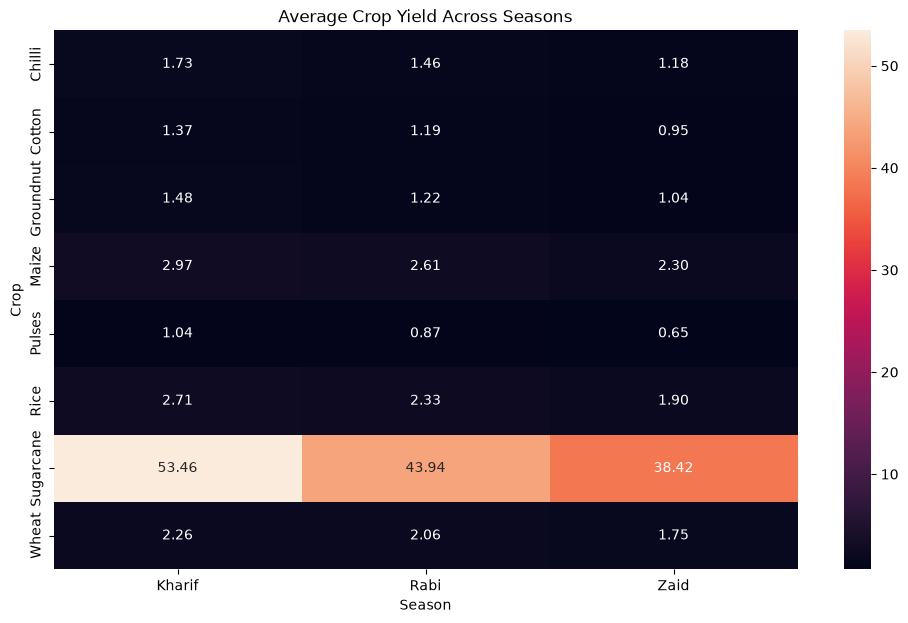

In [34]:
# Visualization:

plt.figure(figsize=(12,7))

sns.heatmap(
    crop_season_yield,
    annot=True,
    fmt=".2f"
)
plt.title("Average Crop Yield Across Seasons")
plt.xlabel("Season")
plt.ylabel("Crop")
plt.show()

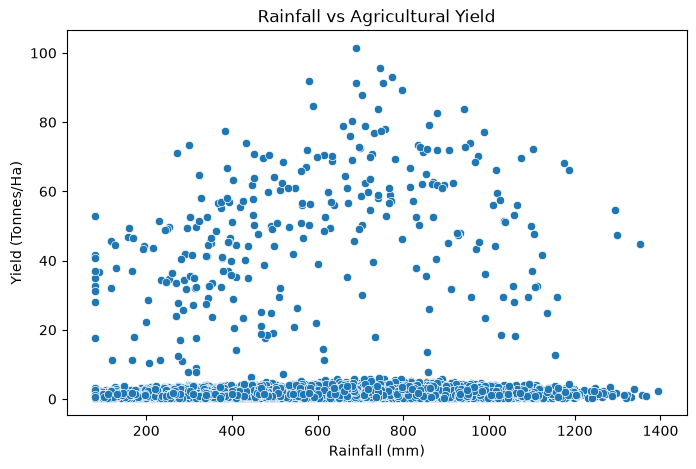

In [35]:
# Environmental analysis
# Now investigate rainfall.

plt.figure(figsize=(8,5))
sns.scatterplot(
    data=data,
    x="Rainfall_mm",
    y="Yield_Tonnes_Ha"
)
plt.title("Rainfall vs Agricultural Yield")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Yield (Tonnes/Ha)")
plt.show()

In [36]:
# Calculate correlation:

data["Rainfall_mm"].corr(data["Yield_Tonnes_Ha"])

np.float64(0.030853016982720992)

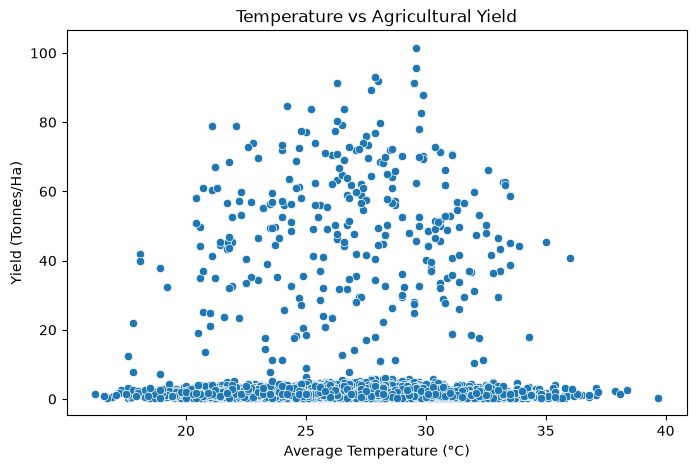

In [37]:
# Temperature vs yield
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=data,
    x="Avg_Temperature_C",
    y="Yield_Tonnes_Ha"
)
plt.title("Temperature vs Agricultural Yield")
plt.xlabel("Average Temperature (°C)")
plt.ylabel("Yield (Tonnes/Ha)")
plt.show()

In [38]:
# Correlation:

data["Avg_Temperature_C"].corr(
    data["Yield_Tonnes_Ha"]
)

np.float64(0.00934946661730157)

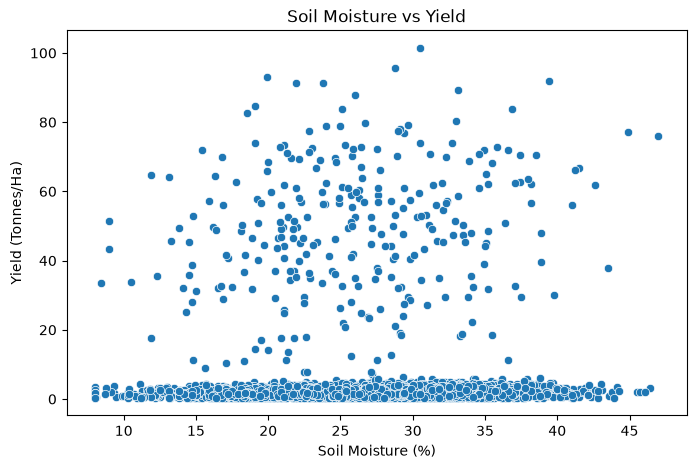

In [39]:
# Soil moisture vs yield
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=data,
    x="Soil_Moisture_pct",
    y="Yield_Tonnes_Ha"
)
plt.title("Soil Moisture vs Yield")
plt.xlabel("Soil Moisture (%)")
plt.ylabel("Yield (Tonnes/Ha)")
plt.show()

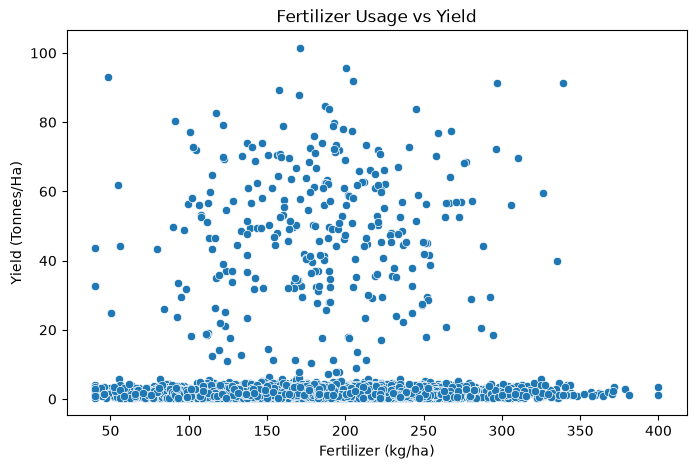

In [40]:
# Fertilizer vs yield

plt.figure(figsize=(8,5))
sns.scatterplot(
    data=data,
    x="Fertilizer_kg_ha",
    y="Yield_Tonnes_Ha"
)
plt.title("Fertilizer Usage vs Yield")
plt.xlabel("Fertilizer (kg/ha)")
plt.ylabel("Yield (Tonnes/Ha)")
plt.show()

In [41]:
# Correlation:

data["Fertilizer_kg_ha"].corr(
    data["Yield_Tonnes_Ha"]
)

np.float64(0.000561889279513486)

In [42]:
# Irrigation analysis
# Check irrigation methods:

data["Irrigation_Method"].value_counts()

Irrigation_Method
Flood        1310
Rainfed      1041
Drip          915
Sprinkler     734
Name: count, dtype: int64

In [43]:
irrigation_performance = data.groupby("Irrigation_Method").agg({
    "Yield_Tonnes_Ha": "mean",
    "Profit_INR": "mean",
    "Water_Used_m3": "mean",
    "Water_Efficiency_t_per_1000m3": "mean"
}).round(2)

irrigation_performance

,Yield_Tonnes_Ha,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3
Irrigation_Method,,,,
Drip,6.62,219626.00,5918.75,6.27
Flood,4.90,73354.02,8026.47,3.44
Rainfed,4.61,79050.37,3549.55,7.56
Sprinkler,5.19,91121.08,6208.26,4.67


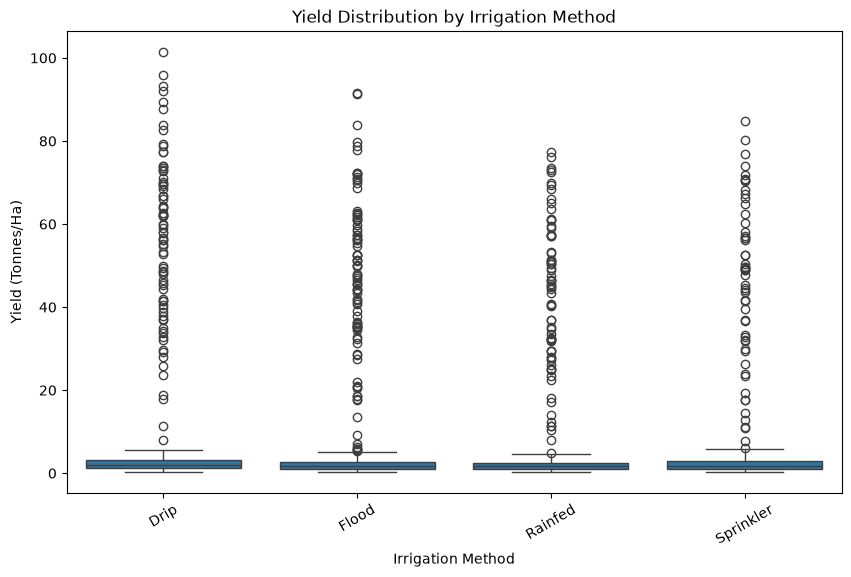

In [44]:
# Visualization:

plt.figure(figsize=(10,6))

sns.boxplot(
    data=data,
    x="Irrigation_Method",
    y="Yield_Tonnes_Ha"
)
plt.title("Yield Distribution by Irrigation Method")
plt.xlabel("Irrigation Method")
plt.ylabel("Yield (Tonnes/Ha)")
plt.xticks(rotation=30)
plt.show()

In [45]:
# Economic analysis

economic_data = data[
    ["Total_Cost_INR",
     "Revenue_INR",
     "Profit_INR",
     "Market_Price_INR_Tonne"]
]
economic_data.describe()

,Total_Cost_INR,Revenue_INR,Profit_INR,Market_Price_INR_Tonne
count,4.000000e+03,4.000000e+03,4.000000e+03,4000.000000
mean,5.263036e+05,6.378600e+05,1.115565e+05,44714.166250
std,2.944191e+05,6.369747e+05,5.450819e+05,30266.161922
min,2.682600e+04,6.107000e+03,-1.019223e+06,2594.000000
25%,2.745775e+05,2.075172e+05,-1.487318e+05,21429.250000
50%,5.190825e+05,4.568305e+05,3.673000e+03,25913.000000
75%,7.619965e+05,8.368748e+05,2.161878e+05,68279.000000
max,1.349990e+06,5.080900e+06,4.345421e+06,131240.000000


In [46]:
# Profit by crop
crop_profit = (
    data.groupby("Crop")["Profit_INR"]
    .mean()
    .sort_values(ascending=False)
)
crop_profit



Crop
Sugarcane    817187.986885
Chilli       750878.342233
Cotton       124546.915354
Groundnut     44858.120283
Pulses        -4238.052419
Maize        -83978.326679
Rice        -102213.504348
Wheat       -123398.337134
Name: Profit_INR, dtype: float64

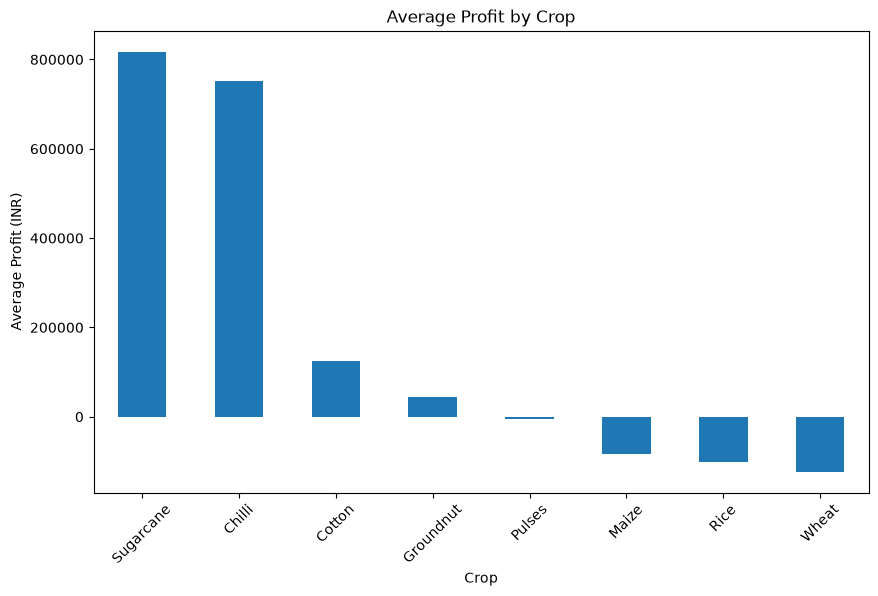

In [47]:
# Plot:

plt.figure(figsize=(10,6))
crop_profit.plot(kind="bar")
plt.title("Average Profit by Crop")
plt.xlabel("Crop")
plt.ylabel("Average Profit (INR)")
plt.xticks(rotation=45)
plt.show()

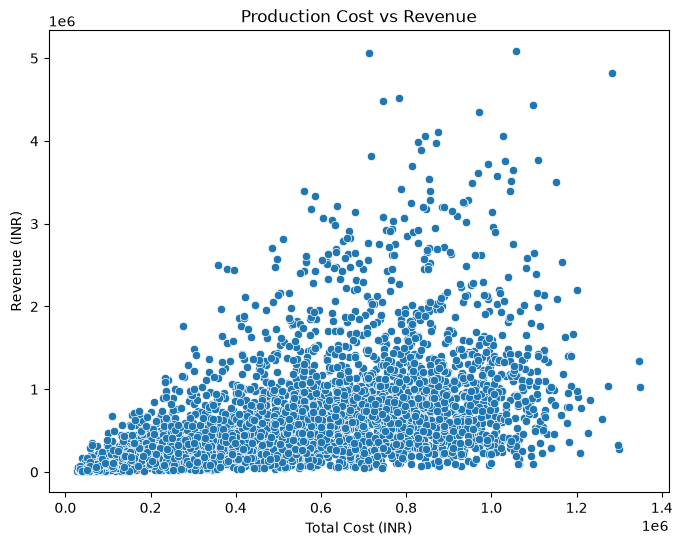

In [48]:
# Revenue vs cost

plt.figure(figsize=(8,6))
sns.scatterplot(
    data=data,
    x="Total_Cost_INR",
    y="Revenue_INR"
)
plt.title("Production Cost vs Revenue")
plt.xlabel("Total Cost (INR)")
plt.ylabel("Revenue (INR)")
plt.show()

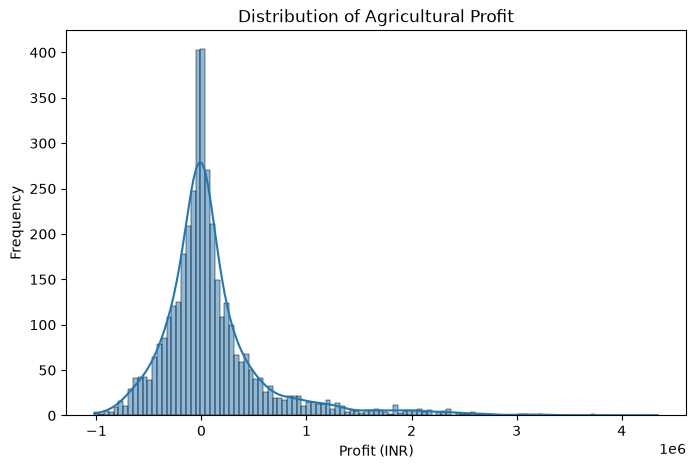

In [49]:
# Profit distribution

plt.figure(figsize=(8,5))

sns.histplot(
    data=data,
    x="Profit_INR",
    kde=True
)
plt.title("Distribution of Agricultural Profit")
plt.xlabel("Profit (INR)")
plt.ylabel("Frequency")
plt.show()

In [50]:
# Correlation analysis
# Select important numerical columns:

correlation_columns = [
    "Rainfall_mm",
    "Avg_Temperature_C",
    "Humidity_pct",
    "Sunlight_Hours_Day",
    "Soil_pH",
    "Soil_Moisture_pct",
    "Nitrogen_kg_ha",
    "Phosphorus_kg_ha",
    "Potassium_kg_ha",
    "Fertilizer_kg_ha",
    "Pesticide_Litre_ha",
    "Seed_Quality_Score",
    "Yield_Tonnes_Ha",
    "Production_Tonnes",
    "Market_Price_INR_Tonne",
    "Total_Cost_INR",
    "Revenue_INR",
    "Profit_INR",
    "Water_Used_m3",
    "Water_Efficiency_t_per_1000m3",
    "Disease_Pest_Risk_pct"
]
correlation_matrix = data[correlation_columns].corr()
correlation_matrix.round(2)

,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
Rainfall_mm,1.00,0.20,0.52,-0.36,0.02,0.52,0.01,0.02,0.03,0.02,0.00,-0.02,0.03,0.02,0.00,0.01,0.10,0.11,0.00,0.06,0.63
Avg_Temperature_C,0.20,1.00,0.14,-0.03,0.03,0.08,0.02,0.01,0.02,0.02,0.01,-0.03,0.01,0.01,0.00,0.04,0.03,0.01,0.02,0.01,0.25
Humidity_pct,0.52,0.14,1.00,-0.30,0.03,0.45,0.00,-0.01,-0.00,0.02,-0.00,-0.05,0.01,0.00,0.00,0.01,0.06,0.06,-0.00,0.03,0.55
Sunlight_Hours_Day,-0.36,-0.03,-0.30,1.00,-0.02,-0.30,0.01,0.00,-0.01,-0.01,-0.02,0.02,-0.02,-0.02,-0.00,-0.00,-0.05,-0.05,-0.01,-0.02,-0.25
Soil_pH,0.02,0.03,0.03,-0.02,1.00,0.03,0.01,0.02,-0.02,-0.01,-0.01,-0.00,-0.02,-0.01,0.02,0.01,-0.01,-0.01,-0.02,-0.01,0.03
Soil_Moisture_pct,0.52,0.08,0.45,-0.30,0.03,1.00,0.01,0.01,0.01,0.01,-0.02,-0.02,0.01,0.00,0.02,0.00,0.08,0.09,0.00,0.03,0.38
Nitrogen_kg_ha,0.01,0.02,0.00,0.01,0.01,0.01,1.00,0.01,0.01,-0.03,0.01,0.01,0.05,0.05,-0.02,0.01,0.08,0.09,0.02,0.05,-0.01
Phosphorus_kg_ha,0.02,0.01,-0.01,0.00,0.02,0.01,0.01,1.00,0.00,0.01,-0.03,-0.01,0.05,0.03,-0.01,-0.02,0.03,0.05,-0.00,0.06,0.03
Potassium_kg_ha,0.03,0.02,-0.00,-0.01,-0.02,0.01,0.01,0.00,1.00,0.02,-0.00,0.01,0.00,0.00,0.01,0.00,0.03,0.03,0.00,0.01,0.01
Fertilizer_kg_ha,0.02,0.02,0.02,-0.01,-0.01,0.01,-0.03,0.01,0.02,1.00,-0.00,0.02,0.00,0.00,-0.00,0.15,0.01,-0.07,0.00,0.01,0.02


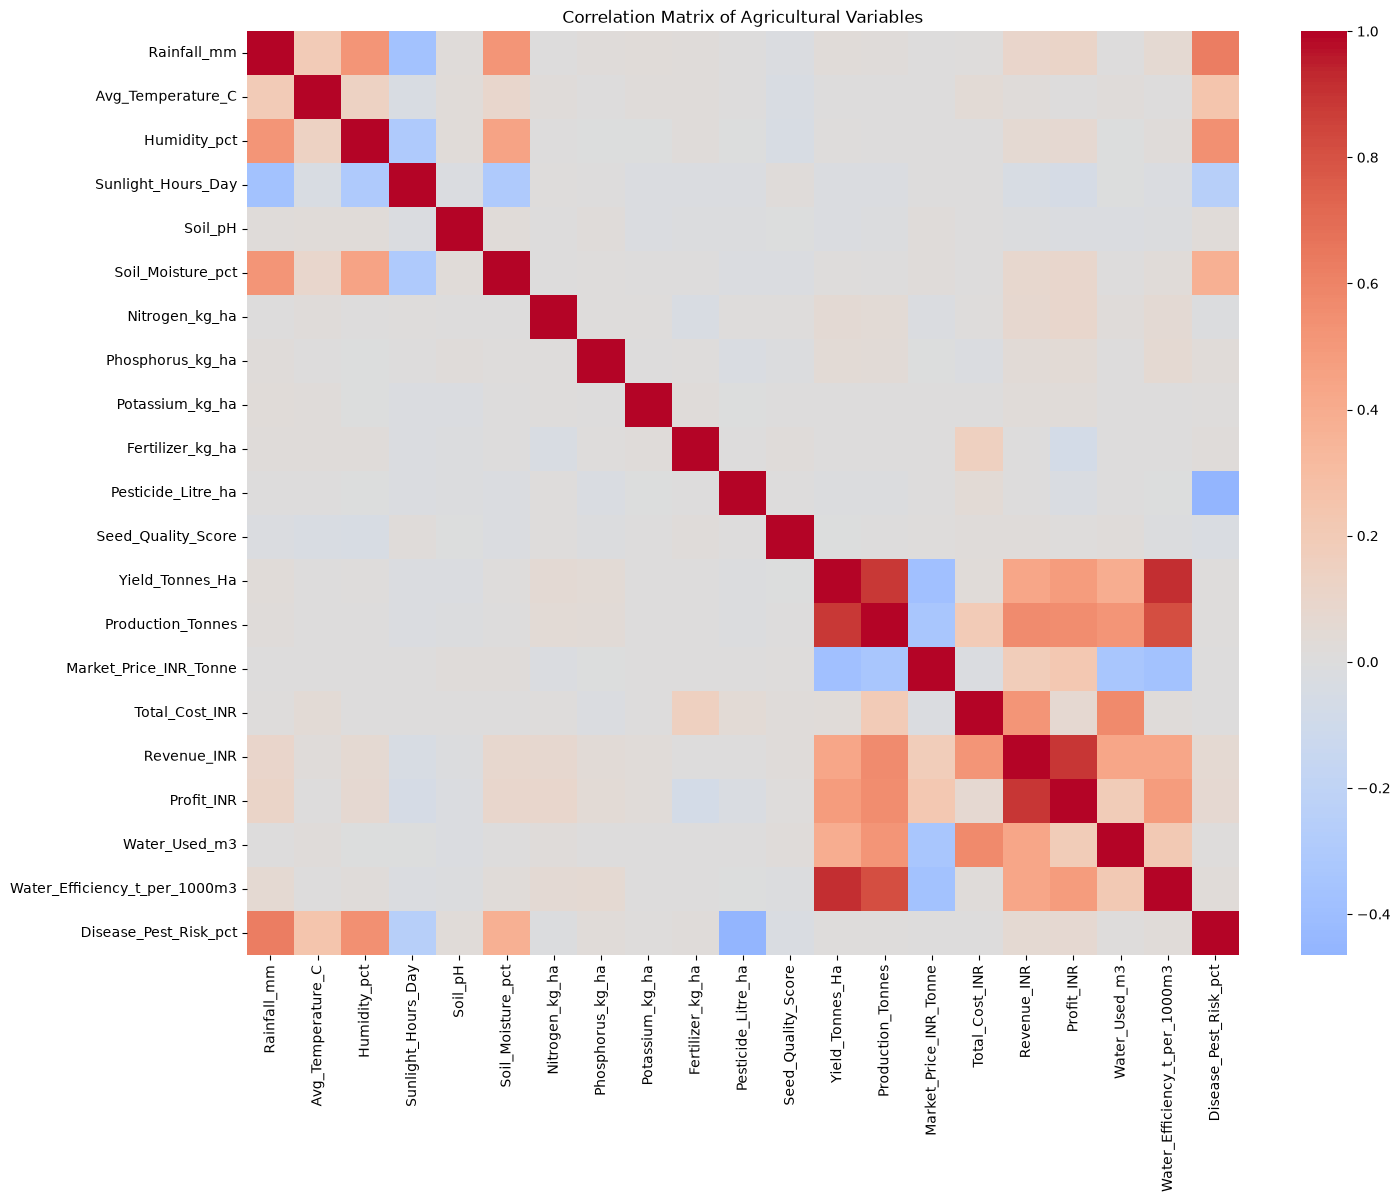

In [51]:
# Correlation heatmap

plt.figure(figsize=(16,12))

sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    center=0
)
plt.title("Correlation Matrix of Agricultural Variables")
plt.show()

In [52]:
# Find strongest relationships
# Instead of manually looking through the huge matrix:

corr_pairs = (
    correlation_matrix
    .where(np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool))
    .stack()
    .sort_values(key=abs, ascending=False)
)
corr_pairs.head(15)

Yield_Tonnes_Ha    Water_Efficiency_t_per_1000m3    0.915438
Revenue_INR        Profit_INR                       0.887331
Yield_Tonnes_Ha    Production_Tonnes                0.885171
Production_Tonnes  Water_Efficiency_t_per_1000m3    0.812143
Rainfall_mm        Disease_Pest_Risk_pct            0.625071
Total_Cost_INR     Water_Used_m3                    0.575978
Production_Tonnes  Revenue_INR                      0.563505
                   Profit_INR                       0.554172
Humidity_pct       Disease_Pest_Risk_pct            0.545093
Rainfall_mm        Humidity_pct                     0.523966
Total_Cost_INR     Revenue_INR                      0.520709
Rainfall_mm        Soil_Moisture_pct                0.515751
Production_Tonnes  Water_Used_m3                    0.515557
Yield_Tonnes_Ha    Profit_INR                       0.489822
Profit_INR         Water_Efficiency_t_per_1000m3    0.489487
dtype: float64

In [53]:
# Statistical analysis
# We can use Pearson correlation.
# For rainfall and yield:

r, p = pearsonr(
    data["Rainfall_mm"],
    data["Yield_Tonnes_Ha"]
)
print("Correlation coefficient:", round(r, 4))
print("P-value:", round(p, 4))

Correlation coefficient: nan
P-value: nan


# Interpretation

- **If p < 0.05:**  
  There is statistically significant evidence of a linear relationship.

- **If p >= 0.05:**  
  There is insufficient evidence of a statistically significant linear relationship.

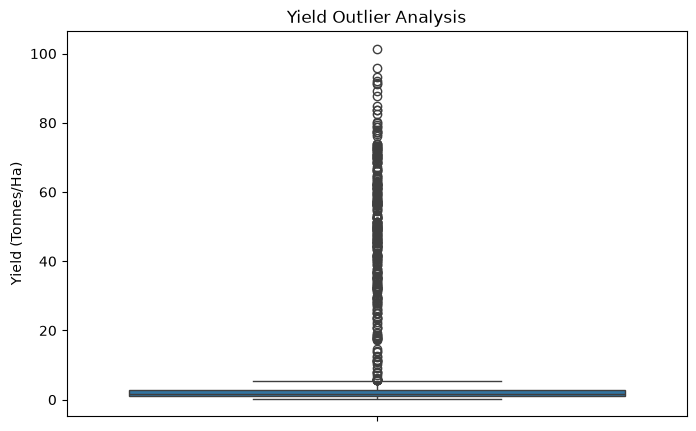

In [54]:
# Outlier analysis
plt.figure(figsize=(8,5))

sns.boxplot(
    data=data,
    y="Yield_Tonnes_Ha"
)
plt.title("Yield Outlier Analysis")
plt.ylabel("Yield (Tonnes/Ha)")
plt.show()

In [55]:
# We can mathematically identify potential outliers:

Q1 = data["Yield_Tonnes_Ha"].quantile(0.25)
Q3 = data["Yield_Tonnes_Ha"].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
yield_outliers = data[
    (data["Yield_Tonnes_Ha"] < lower_bound) |
    (data["Yield_Tonnes_Ha"] > upper_bound)
]
len(yield_outliers)

302

In [56]:
# Regional analysis
# State performance

state_performance = data.groupby("State").agg({
    "Yield_Tonnes_Ha": "mean",
    "Profit_INR": "mean",
    "Revenue_INR": "mean"
}).round(2)

state_performance


,Yield_Tonnes_Ha,Profit_INR,Revenue_INR
State,,,
Andhra Pradesh,4.65,73453.53,606663.66
Gujarat,5.70,117568.24,654692.86
Karnataka,5.73,119422.34,653426.18
Madhya Pradesh,5.03,86840.76,597558.36
Maharashtra,5.03,135428.86,650032.67
Punjab,6.12,136025.64,686225.70
Tamil Nadu,4.90,117744.75,629093.42
Telangana,5.08,108829.62,628784.53


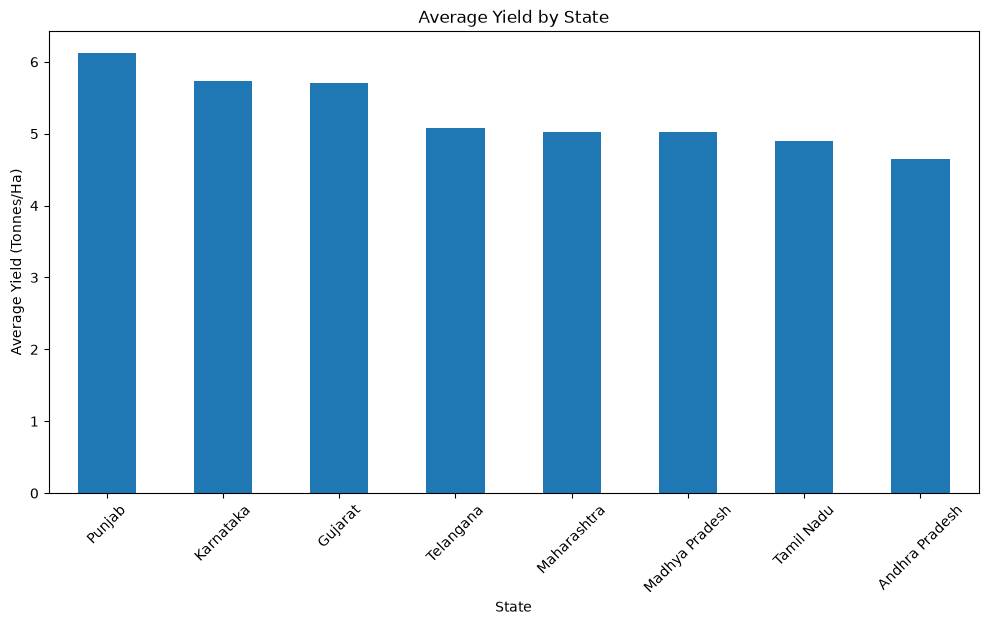

In [57]:
# Plot:

state_yield = (
    data.groupby("State")["Yield_Tonnes_Ha"]
    .mean()
    .sort_values(ascending=False)
)
plt.figure(figsize=(12,6))
state_yield.plot(kind="bar")
plt.title("Average Yield by State")
plt.xlabel("State")
plt.ylabel("Average Yield (Tonnes/Ha)")
plt.xticks(rotation=45)
plt.show()

In [58]:
# Disease and pest risk

season_risk = (
    data.groupby("Season")["Disease_Pest_Risk_pct"]
    .mean()
    .sort_values(ascending=False)
)
season_risk

Season
Kharif    54.467903
Rabi      40.482114
Zaid      38.216667
Name: Disease_Pest_Risk_pct, dtype: float64

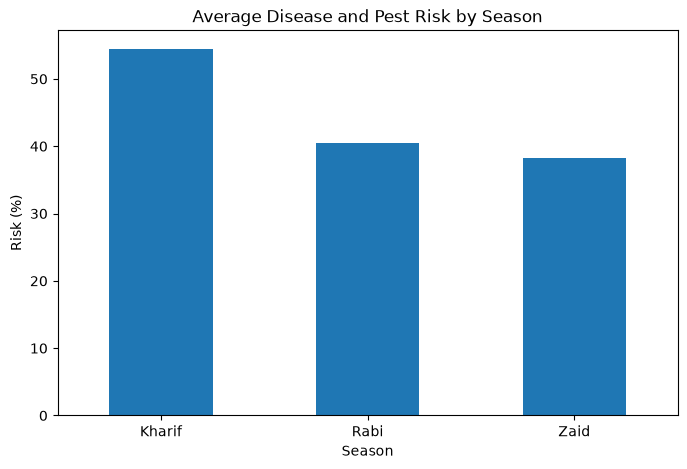

In [59]:
#Plot:

plt.figure(figsize=(8,5))

season_risk.plot(kind="bar")

plt.title("Average Disease and Pest Risk by Season")
plt.xlabel("Season")
plt.ylabel("Risk (%)")

plt.xticks(rotation=0)
plt.show()

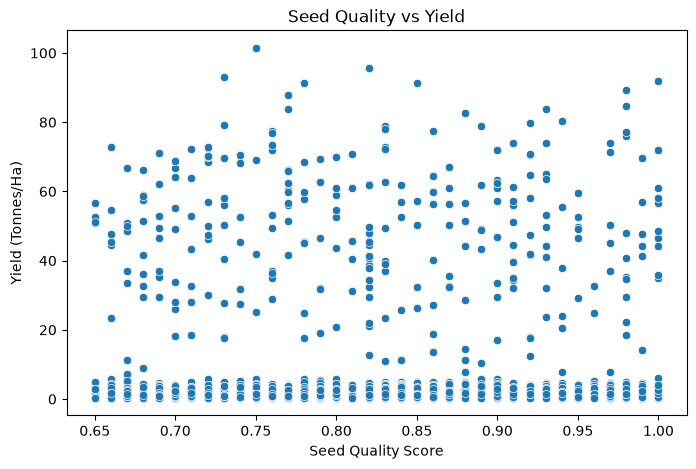

In [60]:
# Seed quality analysis
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=data,
    x="Seed_Quality_Score",
    y="Yield_Tonnes_Ha"
)

plt.title("Seed Quality vs Yield")
plt.xlabel("Seed Quality Score")
plt.ylabel("Yield (Tonnes/Ha)")

plt.show()

In [61]:
# Correlation:

data["Seed_Quality_Score"].corr(
    data["Yield_Tonnes_Ha"]
)

np.float64(-0.006736713918859163)

In [62]:
# Build a final summary table

final_summary = data.groupby("Season").agg(
    Average_Yield=("Yield_Tonnes_Ha", "mean"),
    Average_Profit=("Profit_INR", "mean"),
    Average_Revenue=("Revenue_INR", "mean"),
    Average_Water_Usage=("Water_Used_m3", "mean"),
    Average_Water_Efficiency=("Water_Efficiency_t_per_1000m3", "mean"),
    Average_Disease_Risk=("Disease_Pest_Risk_pct", "mean")
).round(2)

final_summary

,Average_Yield,Average_Profit,Average_Revenue,Average_Water_Usage,Average_Water_Efficiency,Average_Disease_Risk
Season,,,,,,
Kharif,5.64,178914.65,710719.06,6102.20,5.89,54.47
Rabi,5.08,87689.47,601526.05,5846.99,5.19,40.48
Zaid,4.67,-24804.82,519171.90,6419.89,4.41,38.22


In [63]:
# Automatically identify the best season

best_yield_season = season_yield.idxmax()
best_profit_season = season_profit.idxmax()
best_water_efficiency_season = water_efficiency.idxmax()

print("Highest average yield:", best_yield_season)
print("Highest average profit:", best_profit_season)
print("Highest water efficiency:", best_water_efficiency_season)

Highest average yield: Kharif
Highest average profit: Kharif
Highest water efficiency: Kharif


In [64]:
# Automatically identify best crop

best_yield_crop = crop_yield.idxmax()
best_profit_crop = crop_profit.idxmax()

print("Highest average yield crop:", best_yield_crop)
print("Highest average profit crop:", best_profit_crop)

Highest average yield crop: Sugarcane
Highest average profit crop: Sugarcane



# Key Findings

Based on the analysis of the agricultural dataset, the following important
observations were identified:

1. The season with the highest average yield was identified through seasonal
   performance analysis.

2. Seasonal differences were observed in agricultural profit and revenue.

3. Crop performance varied across different seasons, indicating that seasonal
   conditions may be associated with crop productivity.

4. Environmental variables such as rainfall, temperature, and soil moisture
   were examined to understand their association with agricultural yield.

5. Differences in irrigation methods were observed in terms of yield,
   water usage, and water efficiency.

6. Resource variables including fertilizer and nutrient usage were analyzed
   to understand their relationship with agricultural outcomes.

7. Economic indicators such as production cost, revenue, market price,
   and profit showed differences across agricultural categories.

8. Correlation analysis helped identify variables with stronger statistical
   associations with yield and profit.

9. Outlier analysis identified unusual observations that may require
   further investigation.

10. The results provide evidence-based insights that can support further
    seasonal agricultural planning.

# Recommendations

Based on the findings of the analysis:

1. Agricultural planning should consider seasonal differences in yield and
   profitability.

2. Crops showing stronger performance during specific seasons can be
   considered when planning seasonal cultivation.

3. Irrigation practices should be evaluated based on both productivity and
   water efficiency.

4. Resource usage such as fertilizer and water should be monitored to
   identify efficient farming practices.

5. Environmental conditions such as rainfall, temperature, and soil moisture
   should be considered when evaluating expected agricultural performance.

6. Areas with relatively high disease or pest risk may require additional
   monitoring and preventive planning.

7. Unusual observations identified through outlier analysis should be
   investigated further rather than automatically removed.

8. Future agricultural planning can combine environmental, production,
   resource, and economic indicators for better decision-making.

# Conclusion

This project analyzed agricultural performance across different seasons,
crops, geographical areas, environmental conditions, resource usage, and
economic indicators.

The analysis included data cleaning, descriptive statistics, seasonal
comparison, crop analysis, environmental analysis, resource usage analysis,
economic analysis, correlation analysis, visualization, statistical testing,
and outlier identification.

The findings demonstrate that agricultural performance can vary across
different seasonal and farming conditions. The analysis also highlights
relationships between environmental factors, farming resources, production,
and economic outcomes.

Overall, the project demonstrates how data analytics can be used to transform
raw agricultural data into meaningful insights that can support evidence-based
agricultural planning and further investigation.